# Continuous Hopfield network



| Date | Who | Mail |  What |
| ---  | --- | ---  | ---   |     
| Dic 26, 2025 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Initial code created using Gemini 3.0 |
| Dic 27, 2025 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Code, formulation and comments improvements |

This notebook extends the concepts from the discrete version, moving from "digital switches" to "analog circuits." This is particularly useful for modeling smooth, continuous data or solving complex optimization problems where variables aren't just strictly "on" (+1) or "off" (-1).

## 1. Some mathematical elements

In the discrete Hopfield network, neurons snapped instantly between -1 and +1. The continuous Hopfield network, however, models neurons as biological or electrical units that charge and discharge over time.

### 1.1 The Neuron Model

Instead of a binary state , each neuron  has two variables:

1. **Internal Potential ($v_i$):** The total input current accumulating in the neuron.
2. **Output State ($x_i$):** The actual firing rate or activation, determined by a non-linear function of $v_i$ (Haykin, eq. 13.23):
$$
x_i = \phi_i(v_i) = \tanh\left(a_i v_i\right)
$$
* $\phi_i$: squashes the output between -1 and 1.
* $a_i$: Gain parameter:
    * High $a_i$ makes the sigmoid steep (approaching a binary step function). The network behaves almost exactly like the discrete version, forcing values to -1 or 1 rapidly.
    * Low $a_i$ makes a smoother version of the sigmoid. The network may settle in a "fuzzy" state (values near 0) rather than making a decision.
    * We could use **annealing**. This is a powerful technique that starts with low $a_i$ (smooth search) and slowly increases it (sharpening decisions). This helps find the global minimum.

### 1.2 The neurodynamic model
The system evolves according to a system of coupled non-linear differential equations. The rate of change of the internal potential $v_j$ is (Haykin, eq. 13.20):
$$
C_j\frac{\mathrm{d} v_j(t)}{\mathrm{d}t} = -\frac{v_j(t)}{R_j} + \sum_{i=1}^{N} w_{ji} x_i(t) + I_j \quad \text{for } j=1,\ldots,N.
$$
Here:
* $C_j$: damping/capacitive term.
* $R_j$: resistance term.
* $I_j$: externally applied bias (current source).
* $w_{ji}$: synaptic weights (conductances).
* $v_j(t)$: induced local field.
* $x_i(t)$: neuron input/output.
* $\sum_{i=1}^{N} w_{ji} x_i(t) + I_j$:  weighted input from other neurons plus current source term (input/feedback of the system).

### 1.3 The Lyapunov (energy) function
Just like the discrete version, the continuous Hopfield networks minimize a Lyapunov (energy) function (Haykin, eq. 13.28):
$$
E(t) = -\frac{1}{2} \sum_{i=1}^N \sum_{j=1}^N w_{ji} x_i(t) x_j(t) + \sum_{j=1}^N \frac{1}{R_j} \int_{0}^{x_i} \phi_j^{-1}(x) \,\mathrm{d}x - \sum_{j=1}^N I_j x_j(t).
$$

---

## 2. Implementation from Scratch

We will use **Euler's Method** for numerical integration. This integrates $\frac{\mathrm{d} v_j(t)}{\mathrm{d}t}$ by taking small discrete time steps ($\Delta t$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy

# Set seed for reproducibility
np.random.seed(42)

class ContinuousHopfieldNetwork:
    def __init__(self, N, R=1.0, I=0.0, a=5.0):
        """
        Initialize continuous Hopfield network

        N: Number of neurons
        R: Time constant (decay rate)
        a: Gain of the activation function (steepness)
        """
        self.N = N
        self.R = R
        self.I = I
        self.a = a
        self.W = np.zeros((N, N)) # weights

    def phi(self, v):
        """Hyperbolic tangent activation function mapping v to [-1, 1]."""
        x = np.tanh(self.a*v)
        return x

    def inv_phi(self, x):
        """Inverse hyperbolic tangent activation function."""
        # We add a tiny epsilon to avoid division by zero if input is exactly 1
        x = np.copy(x)
        v = np.arctanh(np.clip(x, -0.9999, 0.9999))/self.a
        return v

    def integral_inv_phi_0_L(self, L):
        """
        Calculates integral(inv_phi(x), (x, 0, L)).

        import sympy as sp
        x, L, a = sp.symbols("x, L, a")
        sp.integrate(sp.atanh(x)/a, (x, 0, L))

        outputs:
        (L*atanh(L) + log(L + 1) - atanh(L))/a
        """

        # We add a tiny epsilon to avoid -inf or +inf if L is exactly -1 or +1
        arctanh_L = np.arctanh(np.clip(L, -0.9999, 0.9999))
        return (L*arctanh_L + np.log1p(L) - arctanh_L)/self.a

    def store(self, patterns):
        """
        Store patterns (the fundamental memories) using Hebb's learning rule. It
        adjusts weights based on the correlation between weights and patterns.

        patterns: list of patterns or fundamental memories (arrays of +1 and -1)
        """
        for p in patterns: # this iterates M times; M = number of patterns
            self.W += np.outer(p, p)

        # Normalize weights W by the size N of the network
        self.W /= self.N

        # Set diagonal to zero (no self-connections)
        np.fill_diagonal(self.W, 0)

    def energy(self, x):
        """
        Energy calculation for the continuous Hopfield network.
        E = -0.5*x^T*W*x + sum(1/Rj*integral(invphi_j(x), x, 0, xj)) - sum(Ij*xj)
        """
        E = - 0.5*x@self.W@x \
            + np.sum(self.integral_inv_phi_0_L(x))/self.R \
            - self.I*np.sum(x)
        return E

    def retrieve(self, initial_state_x, dt=0.1, steps=1000):
        """
        Simulate the network dynamics using Euler method integration.

        initial_state_x: Initial state
        dt:    Time step size for integration
        steps: Number of integration steps
        I: Strength of external input (I_j) usually set to 0 during relaxation
        """
        # Initialize internal potential (inverse of activation) to match input
        # We add a tiny epsilon to avoid division by zero if input is exactly 0
        v = self.inv_phi(initial_state_x)

        energy_history = []

        for _ in range(steps):
            # State
            x = self.phi(v)

            # Calculate dv/dt
            dv_dt = -v/self.R + self.W@x + self.I

            # Euler integration: v[t+1] = v[t] + dv/dt * dt
            v = v + dv_dt*dt

            # Record energy
            energy_history.append(self.energy(x))

        return self.phi(v), energy_history

---

## 3. Practical Example: Grayscale Pattern Restoration

In the discrete case, pixels were black or white. Here, we can theoretically handle values in between, though Hopfield networks strongly prefer "corner" states (saturated -1 or +1). We will demonstrate how the continuous dynamics allow the network to smoothly slide from a "grey, noisy" state to a "crisp, clear" state.

### Step 3.1: Defining Grayscale-like Patterns

We will use a 8x8 grid.

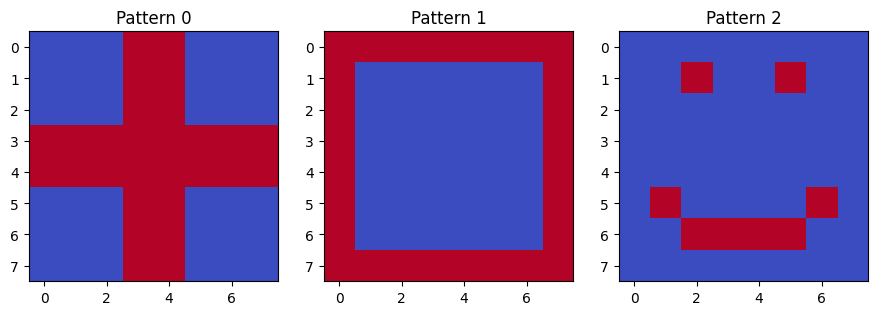

In [2]:
def plot_pattern(data, title, ax):
    """Helper to plot a binary grid (pattern)"""
    size = int(np.sqrt(len(data)))
    ax.imshow(data.reshape(size, size), cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_title(title)
    #ax.axis('off')

# Create 3 8x8 patterns (flattened to 64 elements)
patterns = 3 * [None]

# Cross
p = np.full((8, 8), -1)
p[3:5, :] = 1
p[:, 3:5] = 1
patterns[0] = p.flatten()

# Border
p = np.full((8, 8), -1)
p[0, :] = 1; p[-1, :] = 1
p[:, 0] = 1; p[:, -1] = 1
patterns[1] = p.flatten()

# Smiley Face
p = np.full((8, 8), -1)
p[1, 2] = 1; p[1, 5] = 1     # Eyes
p[5, 1] = 1; p[5, 6] = 1     # Mouth corners
p[6, 2:6] = 1                # Smile bottom
patterns[2] = p.flatten()

# Visualize the patterns
fig, ax = plt.subplots(1, 3, figsize=(9, 3))
for i in range(1*3):
    plot_pattern(patterns[i], f"Pattern {i}", ax.flatten()[i])
plt.tight_layout()
plt.show()

### Step 3.2: Adding "Continuous" Noise

Instead of just flipping bits (binary noise), we will add **Gaussian Noise**. This creates "gray" pixels—values like 0.4 or -0.2—which don't exist in the discrete world but do exist here.

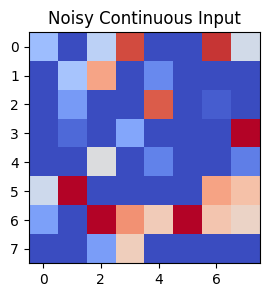

In [3]:
def add_continuous_noise(pattern, noise_scale=0.5):
    noise = np.random.normal(0, noise_scale, size=pattern.shape)
    # Clip to keep within valid range
    noisy = np.clip(pattern + noise, -1, +1)
    return noisy

# Generate test case
target = patterns[2]
noisy_input = add_continuous_noise(target, noise_scale=1.2) # Heavy noise

fig, ax = plt.subplots(figsize=(3, 3))
plot_pattern(noisy_input, "Noisy Continuous Input", ax)
plt.show()

### Step 3.3: Running the Simulation

We initialize the network, train it, and then simulate the differential equations to watch the noise "melt away" into the correct pattern.

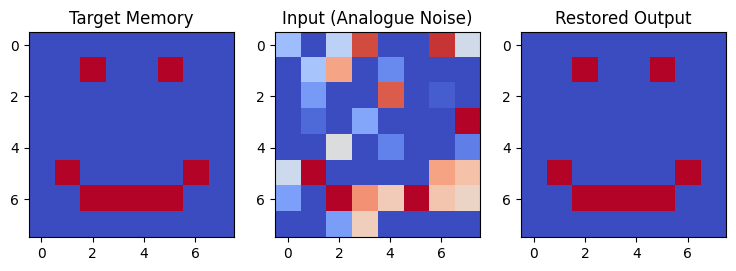

In [4]:
# Initialize Network
chn = ContinuousHopfieldNetwork(8*8, R=1.0, I=0.0, a=10.0)

# Store the patterns
chn.store(patterns)

# Retrieve original pattern from noisy pattern
restored_state, energy = chn.retrieve(noisy_input, dt=0.1, steps=100)

# --- Visualization ---
fig, ax = plt.subplots(1, 3, figsize=(9, 3))

plot_pattern(target,         "Target Memory",          ax[0])
plot_pattern(noisy_input,    "Input (Analogue Noise)", ax[1])
plot_pattern(restored_state, "Restored Output",        ax[2])

plt.show()

### Step 3.4: Energy Landscape Convergence

The key theoretical proof of Hopfield networks is that Energy always decreases (or stays constant). Let's verify this property.

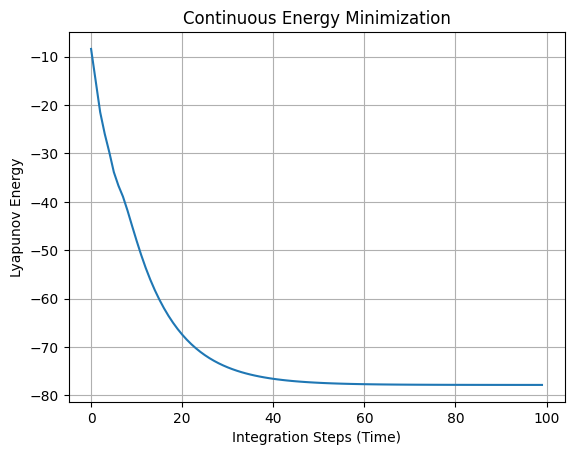

In [5]:
plt.figure()
plt.plot(energy)
plt.title("Continuous Energy Minimization")
plt.xlabel("Integration Steps (Time)")
plt.ylabel("Lyapunov Energy")
plt.grid(True)
plt.show()

---

## 4. Why use Continuous over Discrete?

1. **Hardware Implementation:** Continuous networks are the mathematical basis for building neural networks on analog chips (neuromorphic computing), where voltage varies smoothly.
2. **Optimization:** Continuous networks are famously used to solve the **Traveling Salesman Problem (TSP)**. By mapping valid "tours" to energy minima, the continuous dynamics allow the network to escape shallow local minima better than the discrete "flipping" version.
3. **Stability:** The differential equations provide a smoother convergence trajectory, reducing the oscillation (blinking states) sometimes seen in synchronous discrete networks.
